<a href="https://colab.research.google.com/github/Kartikiscalm/IML-LAB-/blob/labs/B25EC1018_Vyom_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A - Linear Regression


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the built-in diabetes dataset
diabetes = load_diabetes(as_frame=True)
diabetes_df = diabetes.frame.copy()

print("Dataset successfully loaded.")

Dataset successfully loaded.


## A1. Load, Inspect, and Split

In [2]:
# ---------------- A1: DATA INSPECTION ----------------

print("First five observations:")
display(diabetes_df.head())

print("\nDataset dimensions:")
print(diabetes_df.shape)

print("\nColumn names:")
print(list(diabetes_df.columns))

print("\nColumn data types:")
print(diabetes_df.dtypes)

print("\nMissing values by column:")
print(diabetes_df.isna().sum())

print("\nTarget variable statistics:")
display(diabetes_df["target"].describe())

# Separate predictors and response
feature_data = diabetes_df.drop(columns="target")
target_data = diabetes_df["target"]

# Single fixed split used for both regression models
X_train, X_test, y_train, y_test = train_test_split(
    feature_data,
    target_data,
    test_size=0.20,
    random_state=42
)

# Keep only BMI for the simple regression experiment
X_train_bmi = X_train.loc[:, ["bmi"]]
X_test_bmi = X_test.loc[:, ["bmi"]]

print("\nShapes after splitting:")
print("Complete feature matrix:", feature_data.shape)
print("Target vector:", target_data.shape)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)
print("BMI training data:", X_train_bmi.shape)
print("BMI testing data:", X_test_bmi.shape)

First five observations:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Dataset dimensions:
(442, 11)

Column names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Column data types:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Missing values by column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Target variable statistics:


,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000



Shapes after splitting:
Complete feature matrix: (442, 10)
Target vector: (442,)
Training features: (353, 10)
Testing features: (89, 10)
Training target: (353,)
Testing target: (89,)
BMI training data: (353, 1)
BMI testing data: (89, 1)


### A1 Interpretation

The feature matrix is `X`, containing the 10 predictor variables, while `y` is the continuous target representing disease progression. Therefore, the features act as independent variables and the target acts as the dependent variable.

The test data is kept separate from model training so that the final evaluation is performed on observations the model has never seen. This gives a more realistic indication of how the trained model may perform on new data.

## A2. BMI-only Linear Regression

BMI coefficient: 998.5776891375598
BMI intercept: 152.00335421448167

Fitted equation:
y_hat = 998.577689 * bmi + 152.003354

Test-set performance:
MSE  : 4061.825928
RMSE : 63.732456
R2   : 0.233350


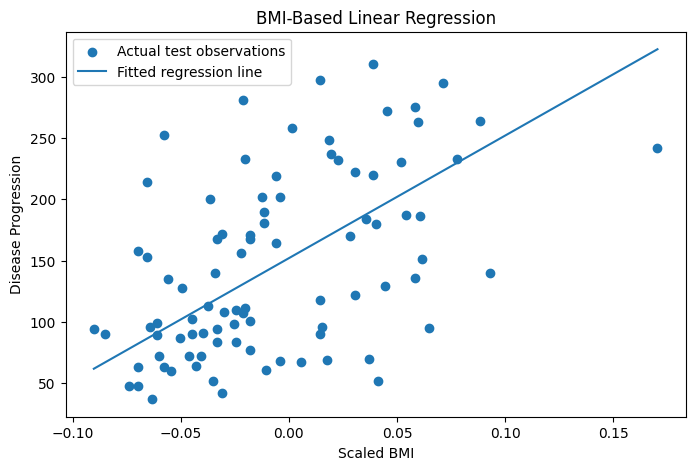

In [3]:
# ---------------- A2: BMI-ONLY MODEL ----------------

bmi_regressor = LinearRegression()
bmi_regressor.fit(X_train_bmi, y_train)

bmi_predictions = bmi_regressor.predict(X_test_bmi)

bmi_weight = bmi_regressor.coef_[0]
bmi_bias = bmi_regressor.intercept_

bmi_mse = mean_squared_error(y_test, bmi_predictions)
bmi_rmse = np.sqrt(bmi_mse)
bmi_r2 = r2_score(y_test, bmi_predictions)

print("BMI coefficient:", bmi_weight)
print("BMI intercept:", bmi_bias)

print("\nFitted equation:")
print(f"y_hat = {bmi_weight:.6f} * bmi + {bmi_bias:.6f}")

print("\nTest-set performance:")
print(f"MSE  : {bmi_mse:.6f}")
print(f"RMSE : {bmi_rmse:.6f}")
print(f"R2   : {bmi_r2:.6f}")

# Sort BMI values before drawing the fitted line
ordered_bmi = np.sort(X_test_bmi["bmi"].to_numpy())
line_values = bmi_regressor.predict(
    pd.DataFrame({"bmi": ordered_bmi})
)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_test_bmi["bmi"],
    y_test,
    label="Actual test observations"
)
plt.plot(
    ordered_bmi,
    line_values,
    label="Fitted regression line"
)

plt.title("BMI-Based Linear Regression")
plt.xlabel("Scaled BMI")
plt.ylabel("Disease Progression")
plt.legend()
plt.show()

### A2 Interpretation

The BMI coefficient is positive, so larger values of the scaled BMI variable are associated with larger predicted disease-progression values in this model. Since the features supplied by the dataset are already scaled, the coefficient should be interpreted in terms of this scaled representation rather than as a change in raw BMI units.

The R² value shows that BMI on its own explains only part of the variation in the target. The remaining variation must therefore be related to other factors that are not included in this single-feature model.

The RMSE is about 63.73, which is fairly large relative to the average target value. This suggests that BMI alone does not provide highly precise predictions.

## A3. All-feature Linear Regression

In [4]:
# ---------------- A3: FULL FEATURE MODEL ----------------

full_regressor = LinearRegression()
full_regressor.fit(X_train, y_train)

full_predictions = full_regressor.predict(X_test)

full_mse = mean_squared_error(y_test, full_predictions)
full_rmse = np.sqrt(full_mse)
full_r2 = r2_score(y_test, full_predictions)

print("All-feature regression results:")
print(f"MSE  : {full_mse:.6f}")
print(f"RMSE : {full_rmse:.6f}")
print(f"R2   : {full_r2:.6f}")

# Required comparison table
regression_comparison = pd.DataFrame([
    {
        "Model": "BMI only",
        "MSE": bmi_mse,
        "RMSE": bmi_rmse,
        "R2": bmi_r2
    },
    {
        "Model": "All 10 features",
        "MSE": full_mse,
        "RMSE": full_rmse,
        "R2": full_r2
    }
])

display(regression_comparison)

All-feature regression results:
MSE  : 2900.193628
RMSE : 53.853446
R2   : 0.452603


,Model,MSE,RMSE,R2
0,BMI only,4061.825928,63.732456,0.233350
1,All 10 features,2900.193628,53.853446,0.452603


### A3 Interpretation

The model using all ten predictors performs better than the BMI-only model on the held-out test data. Its lower MSE and RMSE indicate that its predictions are, on average, closer to the observed target values.

The increase in R² also shows that the complete feature set explains a greater portion of the variation in disease progression. Thus, using the additional variables provides more predictive information than relying on BMI alone.

## A4. Residual and Manual Metric Check

In [5]:
# ---------------- A4: MODEL COMPARISON ----------------

rmse_change = ((full_rmse - bmi_rmse) / bmi_rmse) * 100

print(f"Percentage change in RMSE: {rmse_change:.2f}%")

if full_rmse < bmi_rmse:
    print("The prediction error improved because the all-feature model has a lower RMSE.")
else:
    print("The prediction error worsened because the all-feature model has a higher RMSE.")

# Build coefficient information
coefficient_table = pd.DataFrame({
    "Feature": feature_data.columns,
    "Coefficient": full_regressor.coef_
})

coefficient_table["Abs_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    by="Abs_Coefficient",
    ascending=False
).reset_index(drop=True)

print("\nCoefficient ranking:")
display(coefficient_table.head(5))

Percentage change in RMSE: -15.50%
The prediction error improved because the all-feature model has a lower RMSE.

Coefficient ranking:


,Feature,Coefficient,Abs_Coefficient
0,s1,-931.488846,931.488846
1,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
3,s2,518.062277,518.062277
4,bp,347.703844,347.703844


### A4 Interpretation

The RMSE decreases when moving from the BMI-only model to the model containing all ten predictors, so the prediction error improves.

The three features with the greatest absolute coefficient values are **s1, s5, and bmi**. A coefficient with a large magnitude indicates a stronger model-assigned relationship within this particular regression setup, but it should not automatically be interpreted as a causal effect.

Coefficient size can be affected by correlations between predictors, the scaling of the variables, the sample used for training, and the assumptions of linear regression. Therefore, coefficient magnitude alone is not sufficient to establish definitive feature importance.

Mean residual: 3.912840375077808
Largest absolute residual: 154.4933747378822


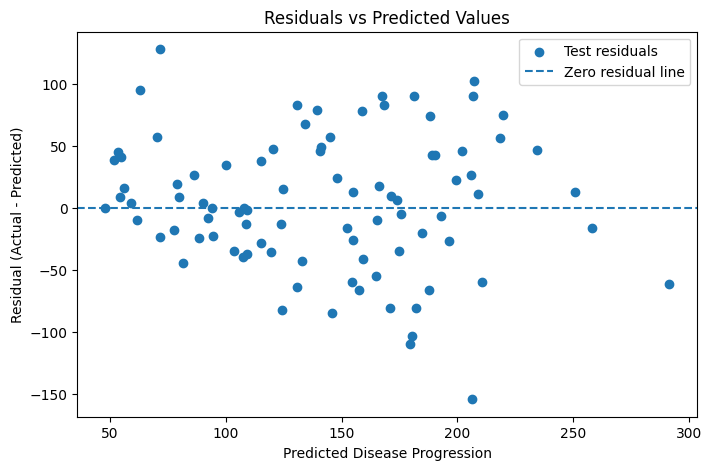


Manual metric calculation:
MSE  : 2900.1936284934814
RMSE : 53.85344583676593
SS_res: 258117.23293591983
SS_tot: 471535.5056179775
R2   : 0.4526027629719195

Verification:
RMSE matches sklearn: True
R2 matches sklearn: True


In [6]:
# ---------------- A5: RESIDUAL ANALYSIS ----------------

residual = y_test.to_numpy() - full_predictions

print("Mean residual:", residual.mean())
print("Largest absolute residual:", np.max(np.abs(residual)))

plt.figure(figsize=(8, 5))
plt.scatter(
    full_predictions,
    residual,
    label="Test residuals"
)
plt.axhline(
    0,
    linestyle="--",
    label="Zero residual line"
)

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Disease Progression")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.show()


# -------- Manual calculation using NumPy --------

actual_values = y_test.to_numpy()
predicted_values = full_predictions

manual_mse = np.mean((actual_values - predicted_values) ** 2)
manual_rmse = np.sqrt(manual_mse)

ss_res = np.sum((actual_values - predicted_values) ** 2)
ss_tot = np.sum(
    (actual_values - np.mean(actual_values)) ** 2
)

manual_r2 = 1 - (ss_res / ss_tot)

print("\nManual metric calculation:")
print("MSE  :", manual_mse)
print("RMSE :", manual_rmse)
print("SS_res:", ss_res)
print("SS_tot:", ss_tot)
print("R2   :", manual_r2)

print("\nVerification:")
print(
    "RMSE matches sklearn:",
    np.allclose(manual_rmse, full_rmse)
)
print(
    "R2 matches sklearn:",
    np.allclose(manual_r2, full_r2)
)

### A5 Interpretation

The residuals are reasonably distributed around the horizontal zero line, which suggests that the model does not consistently overpredict or underpredict the target. There is no strong visible structure in the residual plot that would immediately indicate a major systematic problem.

However, some observations have noticeably larger residuals than the majority. These points represent cases where the model's prediction differs substantially from the actual disease-progression value.

The manual calculations also agree with the corresponding scikit-learn results, confirming that the metric formulas have been implemented correctly.

## Part A Final Report

The all-feature linear regression model is the better choice because it performs more effectively on the unseen test observations than the BMI-only model. The BMI-only model produces an RMSE of about 63.73 and an R² of about 0.233, whereas the model using all ten features reduces the RMSE to about 53.85 and raises R² to about 0.453. This indicates that the additional predictors provide useful information for estimating disease progression.

The residual plot gives information that a single performance metric cannot provide. It allows us to check whether prediction errors are approximately centered around zero and whether there are unusual observations or visible patterns in the errors.

One limitation is that the model assumes a linear relationship between the predictors and the target, which may not capture more complicated relationships. In addition, the dataset contains a limited number of observations.

Finally, good predictive performance only indicates an association useful for prediction. It does not demonstrate that any particular feature directly causes changes in disease progression.

# Part B - Logistic Regression & Binary Classification

In [7]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(2026)
N = 800
temperature_c = rng.normal(72, 10, N).clip(40, 110).round(1)
vibration_mm_s = rng.gamma(shape=2.2, scale=1.4, size=N).clip(0.2, 10).round(2)
pressure_bar = rng.normal(5.5, 0.8, N).clip(3, 8).round(2)
operating_hours = rng.integers(100, 12000, N)
days_since_maintenance = rng.integers(0, 240, N)
load_pct = rng.normal(72, 16, N).clip(20, 100).round(1)

z_true = (-0.8
          + 0.065 * (temperature_c - 72)
          + 0.55 * (vibration_mm_s - 3)
          + 0.18 * (pressure_bar - 5.5)
          + 0.00010 * (operating_hours - 6000)
          + 0.010 * (days_since_maintenance - 100)
          + 0.025 * (load_pct - 72))

p_true = 1 / (1 + np.exp(-z_true))
failure = rng.binomial(1, p_true)

machine_df = pd.DataFrame({
    "temperature_c": temperature_c,
    "vibration_mm_s": vibration_mm_s,
    "pressure_bar": pressure_bar,
    "operating_hours": operating_hours,
    "days_since_maintenance": days_since_maintenance,
    "load_pct": load_pct,
    "failure": failure
})

print("Dataset shape:", machine_df.shape)
machine_df.head()

Dataset shape: (800, 7)


,temperature_c,vibration_mm_s,pressure_bar,operating_hours,days_since_maintenance,load_pct,failure
0,64.1,4.98,6.15,3558,40,82.6,1
1,74.4,2.33,4.96,1057,179,52.6,0
2,53.0,4.10,5.15,9375,208,74.5,1
3,86.0,1.56,5.33,6638,85,76.5,0
4,78.4,3.75,6.77,2641,3,56.1,0


## B1. Data Exploration

First five rows:


,temperature_c,vibration_mm_s,pressure_bar,operating_hours,days_since_maintenance,load_pct,failure
0,64.1,4.98,6.15,3558,40,82.6,1
1,74.4,2.33,4.96,1057,179,52.6,0
2,53.0,4.10,5.15,9375,208,74.5,1
3,86.0,1.56,5.33,6638,85,76.5,0
4,78.4,3.75,6.77,2641,3,56.1,0



Dataset shape:
(800, 7)

Data types:
temperature_c             float64
vibration_mm_s            float64
pressure_bar              float64
operating_hours             int64
days_since_maintenance      int64
load_pct                  float64
failure                     int64
dtype: object

Summary statistics:


,temperature_c,vibration_mm_s,pressure_bar,operating_hours,days_since_maintenance,load_pct,failure
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,72.405375,2.959050,5.477125,6074.791250,120.411250,72.309250,0.395000
std,10.257544,1.942038,0.814423,3478.100465,69.489878,15.244607,0.489157
min,40.000000,0.200000,3.000000,117.000000,0.000000,23.800000,0.000000
25%,65.400000,1.507500,4.890000,2996.750000,58.000000,62.200000,0.000000
50%,72.600000,2.530000,5.525000,6051.500000,127.000000,72.950000,0.000000
75%,79.200000,3.970000,6.060000,9023.250000,178.000000,82.900000,1.000000
max,104.400000,10.000000,7.680000,11999.000000,239.000000,100.000000,1.000000



Missing-value count:
temperature_c             0
vibration_mm_s            0
pressure_bar              0
operating_hours           0
days_since_maintenance    0
load_pct                  0
failure                   0
dtype: int64

Failure-class distribution:


,Count,Percentage
failure,,
0,484,60.5
1,316,39.5


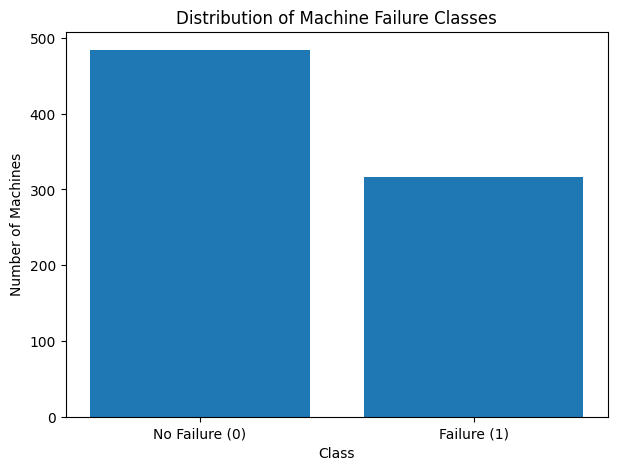

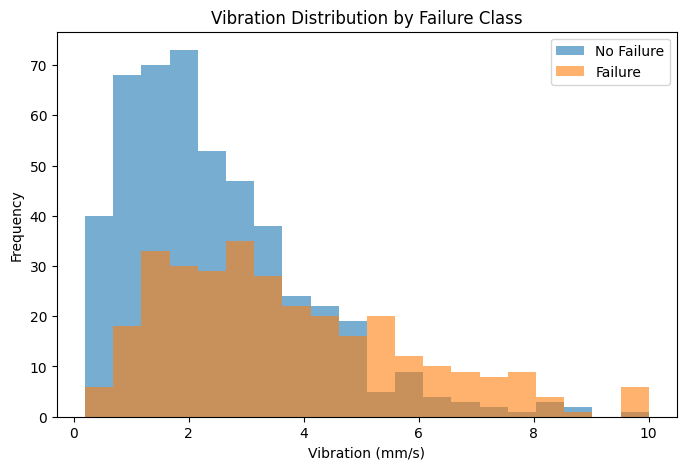

In [8]:
# ---------------- B1: DATA EXPLORATION ----------------

print("First five rows:")
display(machine_df.head())

print("\nDataset shape:")
print(machine_df.shape)

print("\nData types:")
print(machine_df.dtypes)

print("\nSummary statistics:")
display(machine_df.describe())

print("\nMissing-value count:")
print(machine_df.isna().sum())

# Class distribution
class_count = machine_df["failure"].value_counts().sort_index()
class_percentage = machine_df["failure"].value_counts(
    normalize=True
).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": class_count,
    "Percentage": class_percentage
})

print("\nFailure-class distribution:")
display(class_summary)

# Plot 1: class balance
plt.figure(figsize=(7, 5))
plt.bar(
    ["No Failure (0)", "Failure (1)"],
    class_count.values
)
plt.title("Distribution of Machine Failure Classes")
plt.xlabel("Class")
plt.ylabel("Number of Machines")
plt.show()

# Plot 2: compare vibration between the two classes
plt.figure(figsize=(8, 5))

for class_value, label in [(0, "No Failure"), (1, "Failure")]:
    subset = machine_df.loc[
        machine_df["failure"] == class_value,
        "vibration_mm_s"
    ]
    plt.hist(
        subset,
        bins=20,
        alpha=0.6,
        label=label
    )

plt.title("Vibration Distribution by Failure Class")
plt.xlabel("Vibration (mm/s)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### B1 Interpretation

The positive class is **failure = 1**, which represents a machine expected to fail within the next seven days. The negative class, failure = 0, represents machines that do not fail during that period.

The class distribution is not perfectly balanced because non-failure observations make up about 60.5% of the data, while failures account for about 39.5%. Although the imbalance is moderate, accuracy alone should not be relied upon because it does not show whether the model is successfully detecting actual failures or which type of classification error is occurring.

## B2. Split, Scale, and Train

In [9]:
# ---------------- B2: SPLIT, SCALE, TRAIN ----------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

input_columns = [
    "temperature_c",
    "vibration_mm_s",
    "pressure_bar",
    "operating_hours",
    "days_since_maintenance",
    "load_pct"
]

X_machine = machine_df[input_columns]
y_machine = machine_df["failure"]

X_train_machine, X_test_machine, y_train_machine, y_test_machine = (
    train_test_split(
        X_machine,
        y_machine,
        test_size=0.25,
        random_state=42,
        stratify=y_machine
    )
)

# Fit scaling parameters using training observations only
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train_machine)
X_test_scaled = feature_scaler.transform(X_test_machine)

# Logistic regression
failure_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

failure_model.fit(
    X_train_scaled,
    y_train_machine
)

print("Training feature shape:", X_train_machine.shape)
print("Testing feature shape:", X_test_machine.shape)
print("Training target shape:", y_train_machine.shape)
print("Testing target shape:", y_test_machine.shape)

print("\nTraining class percentages:")
print(
    (y_train_machine.value_counts(normalize=True)
     .sort_index() * 100)
)

print("\nTesting class percentages:")
print(
    (y_test_machine.value_counts(normalize=True)
     .sort_index() * 100)
)

Training feature shape: (600, 6)
Testing feature shape: (200, 6)
Training target shape: (600,)
Testing target shape: (200,)

Training class percentages:
failure
0    60.5
1    39.5
Name: proportion, dtype: float64

Testing class percentages:
failure
0    60.5
1    39.5
Name: proportion, dtype: float64


### B2 Interpretation

The observations are divided into training and testing groups using a 75:25 split, while stratification keeps the proportion of the two failure classes similar in both groups.

Standardization is useful because the six predictors are measured on very different numerical scales. It places them on a comparable scale before logistic regression is fitted.

The scaler is learned only from the training observations. If the complete dataset were used to calculate the scaling parameters before the split, information from the test set would indirectly influence the training process. This would constitute data leakage and could make the reported performance look better than it really is.

## B3. Probability and Baseline Evaluation

In [10]:
# ---------------- B3: PREDICTIONS AND PROBABILITIES ----------------

from sklearn.metrics import accuracy_score, confusion_matrix

test_labels = failure_model.predict(X_test_scaled)
test_probabilities = failure_model.predict_proba(X_test_scaled)[:, 1]

print("First ten predicted classes:")
print(test_labels[:10])

print("\nFirst ten failure probabilities:")
print(test_probabilities[:10])


# -------- Manual probability calculation for first test row --------

first_scaled_row = X_test_scaled[0]

linear_score = (
    failure_model.intercept_[0]
    + np.dot(failure_model.coef_[0], first_scaled_row)
)

manual_probability = 1 / (1 + np.exp(-linear_score))

model_probability = test_probabilities[0]

print("\nFirst test observation:")
print("Linear score:", linear_score)
print("Manual sigmoid probability:", manual_probability)
print("Model probability:", model_probability)

print(
    "Probability verification:",
    np.allclose(manual_probability, model_probability)
)


# -------- Majority-class baseline --------

majority_label = y_train_machine.mode().iloc[0]

baseline_predictions = np.full(
    len(y_test_machine),
    majority_label
)

model_accuracy = accuracy_score(
    y_test_machine,
    test_labels
)

baseline_accuracy = accuracy_score(
    y_test_machine,
    baseline_predictions
)

print("\nAccuracy comparison:")
print(f"Logistic regression: {model_accuracy:.3f}")
print(f"Majority baseline  : {baseline_accuracy:.3f}")

if model_accuracy > baseline_accuracy:
    print("The logistic regression model performs better than the baseline.")
else:
    print("The logistic regression model does not outperform the baseline.")

First ten predicted classes:
[0 0 0 0 0 1 0 1 0 0]

First ten failure probabilities:
[0.25271304 0.30184658 0.44424435 0.39648446 0.11004036 0.8731072
 0.12646108 0.62863083 0.09658204 0.31481114]

First test observation:
Linear score: -1.0841946322482983
Manual sigmoid probability: 0.25271304251116067
Model probability: 0.25271304251116067
Probability verification: True

Accuracy comparison:
Logistic regression: 0.705
Majority baseline  : 0.605
The logistic regression model performs better than the baseline.


Confusion Matrix:
[[103  18]
 [ 41  38]]


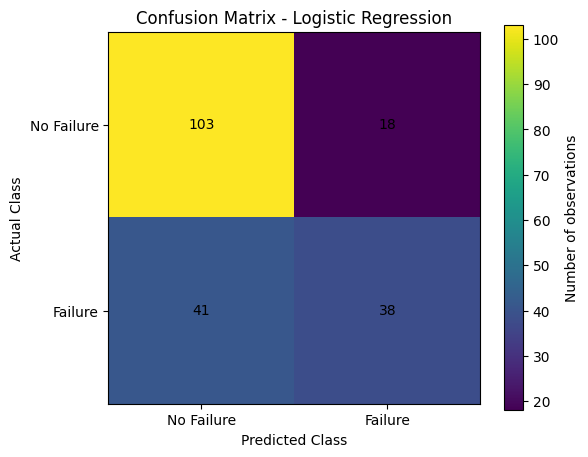

In [11]:
# Confusion matrix for understanding the two error types
cm = confusion_matrix(y_test_machine, test_labels)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["No Failure", "Failure"])
plt.yticks([0, 1], ["No Failure", "Failure"])

for row in range(2):
    for col in range(2):
        plt.text(
            col,
            row,
            cm[row, col],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of observations")
plt.show()

### B3 Interpretation

The logistic regression model produces both a predicted class and a probability that the machine belongs to the failure class. For the first test observation, the probability calculated manually from the model's intercept, coefficients, scaled features, and sigmoid function agrees with the probability returned by `predict_proba()`.

The model also performs better than the majority-class strategy. The logistic regression accuracy is approximately 70.5%, while always predicting the most common class gives about 60.5%.

Therefore, the classifier is extracting useful information from the machine measurements rather than simply predicting the dominant class for every observation.

## B4. Coefficient Analysis

,Feature,Coefficient,Abs_Coefficient
0,vibration_mm_s,0.820191,0.820191
1,temperature_c,0.807966,0.807966
2,days_since_maintenance,0.555360,0.555360
3,load_pct,0.426859,0.426859
4,operating_hours,0.308143,0.308143
5,pressure_bar,0.056156,0.056156


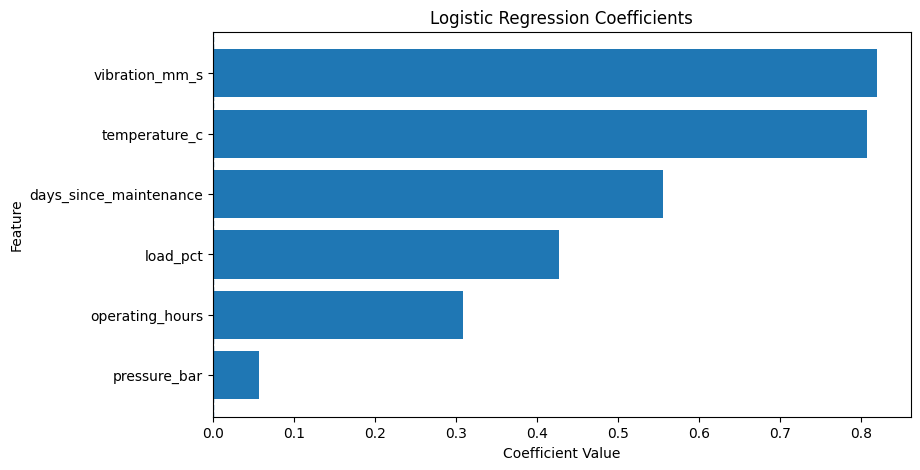

Three largest coefficients by absolute magnitude:
1. vibration_mm_s
2. temperature_c
3. days_since_maintenance


In [12]:
# ---------------- B4: COEFFICIENT ANALYSIS ----------------

model_coefficients = failure_model.coef_.ravel()

coefficient_table = pd.DataFrame({
    "Feature": input_columns,
    "Coefficient": model_coefficients,
    "Abs_Coefficient": np.abs(model_coefficients)
})

coefficient_table = coefficient_table.sort_values(
    "Abs_Coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficient_table)

# Horizontal coefficient plot
plot_data = coefficient_table.sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 5))
plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

top_three = coefficient_table.head(3)["Feature"].tolist()

print("Three largest coefficients by absolute magnitude:")
for position, feature_name in enumerate(top_three, start=1):
    print(f"{position}. {feature_name}")

### B4 Interpretation

The three predictors with the largest absolute logistic-regression coefficients are **vibration_mm_s, temperature_c, and days_since_maintenance**.

A positive coefficient means that, while the other standardized predictors are held constant, increasing that feature tends to move the model toward a higher probability of `failure = 1`. In contrast, a negative coefficient moves the predicted probability toward the non-failure class.

Since the predictors were standardized before training, comparing the coefficient magnitudes is more meaningful than comparing coefficients from variables measured on completely different scales.

Nevertheless, coefficient magnitude should not be treated as proof of causation or as a perfect ranking of feature importance. The values are influenced by relationships between predictors, the particular sample, and the assumptions of the logistic-regression model.

## Part B Final Report

The logistic regression classifier performs better than the majority-class baseline. Its accuracy is approximately 70.5%, compared with about 60.5% for the baseline that always predicts the most common class. This improvement suggests that the machine measurements contain useful information for predicting failures.

For this application, I would be most concerned about false negatives because they represent machines that actually fail but are classified as safe. Missing such machines could result in unexpected breakdowns and potentially higher maintenance costs. I would initially use the standard 0.5 probability threshold because it provides a straightforward separation between the two classes. However, if preventing missed failures is more important, lowering the threshold would make the classifier more sensitive to possible failures.

The strongest coefficients by absolute magnitude are associated with vibration_mm_s, temperature_c, and days_since_maintenance. A major limitation is that the dataset is synthetic, so the measured performance may not transfer directly to real industrial equipment.